## 1 Preprocessing

Steps: 
1. Background Removal: rolling ball
2. Deconvolution:
   2.1 PSF centering
   2.2 richardson lucy

In [1]:
import sys
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np
import stackview
from skimage import io

BASE_DIR = Path.cwd().parent
sys.path.append(str(BASE_DIR))

from src.preprocessing import remove_background_rolling_ball_3d
import src.preprocessing as preproc

In [3]:
# load image 
cnx_img = io.imread(BASE_DIR / 'data/raw/corrected_images/cnx43.tif') # this is a uint16 image

In [4]:
cnx_img.shape

(510, 2048, 1012)

In [5]:
# remove black border on top and left side
cnx_img = cnx_img[:,15:, 3:]

### 1. Background Removal: Rolling Ball

Radius should be bigger than the smallest object and is set to 10 in this project.

In [2]:
deconvolved_img = io.imread(BASE_DIR/'data'/'preprocessed'/'deconvolved_img.tiff')

In [3]:
%time background_subtracted_rolling_10 = remove_background_rolling_ball_3d(deconvolved_img[:, :, :], radius=10, n_jobs=-1)

CPU times: user 4.91 s, sys: 4.95 s, total: 9.86 s
Wall time: 5min 23s


In [4]:
# save the full background_subtracted_rolling_full image 
io.imsave(BASE_DIR / 'data/preprocessed/first_deconvolved_then_background_removed_r10_img.tiff', background_subtracted_rolling_10)

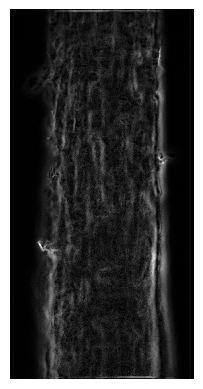

In [12]:
stackview.imshow(background_subtracted_rolling_10[350], vmax = 10000)

In [44]:
%time background_subtracted_rolling_20 = remove_background_rolling_ball_3d(deconvolved_img[270, :, :], radius=20, n_jobs=-1)

CPU times: user 115 ms, sys: 15.6 ms, total: 131 ms
Wall time: 185 ms


In [45]:
%time background_subtracted_rolling_30 = remove_background_rolling_ball_3d(deconvolved_img[270, :, :], radius=30, n_jobs=-1)

CPU times: user 120 ms, sys: 8.86 ms, total: 129 ms
Wall time: 189 ms


In [49]:
# save the full background_subtracted_rolling_full image 
io.imsave(BASE_DIR / 'data/preprocessed/first_deconvolved_then_background_removed_r20_img.tiff', background_subtracted_rolling_20)

In [50]:
# save the full background_subtracted_rolling_full image 
io.imsave(BASE_DIR / 'data/preprocessed/first_deconvolved_then_background_removed_r30_img.tiff', background_subtracted_rolling_30)

In [51]:
# save the full background_subtracted_rolling_full image 
deconvolution_first_background_subtracted_rolling = io.imread(BASE_DIR / 'data/preprocessed/background_removed_and_deconvolved_img.tiff')

### Comparism of Deconvolution then BG substraction 

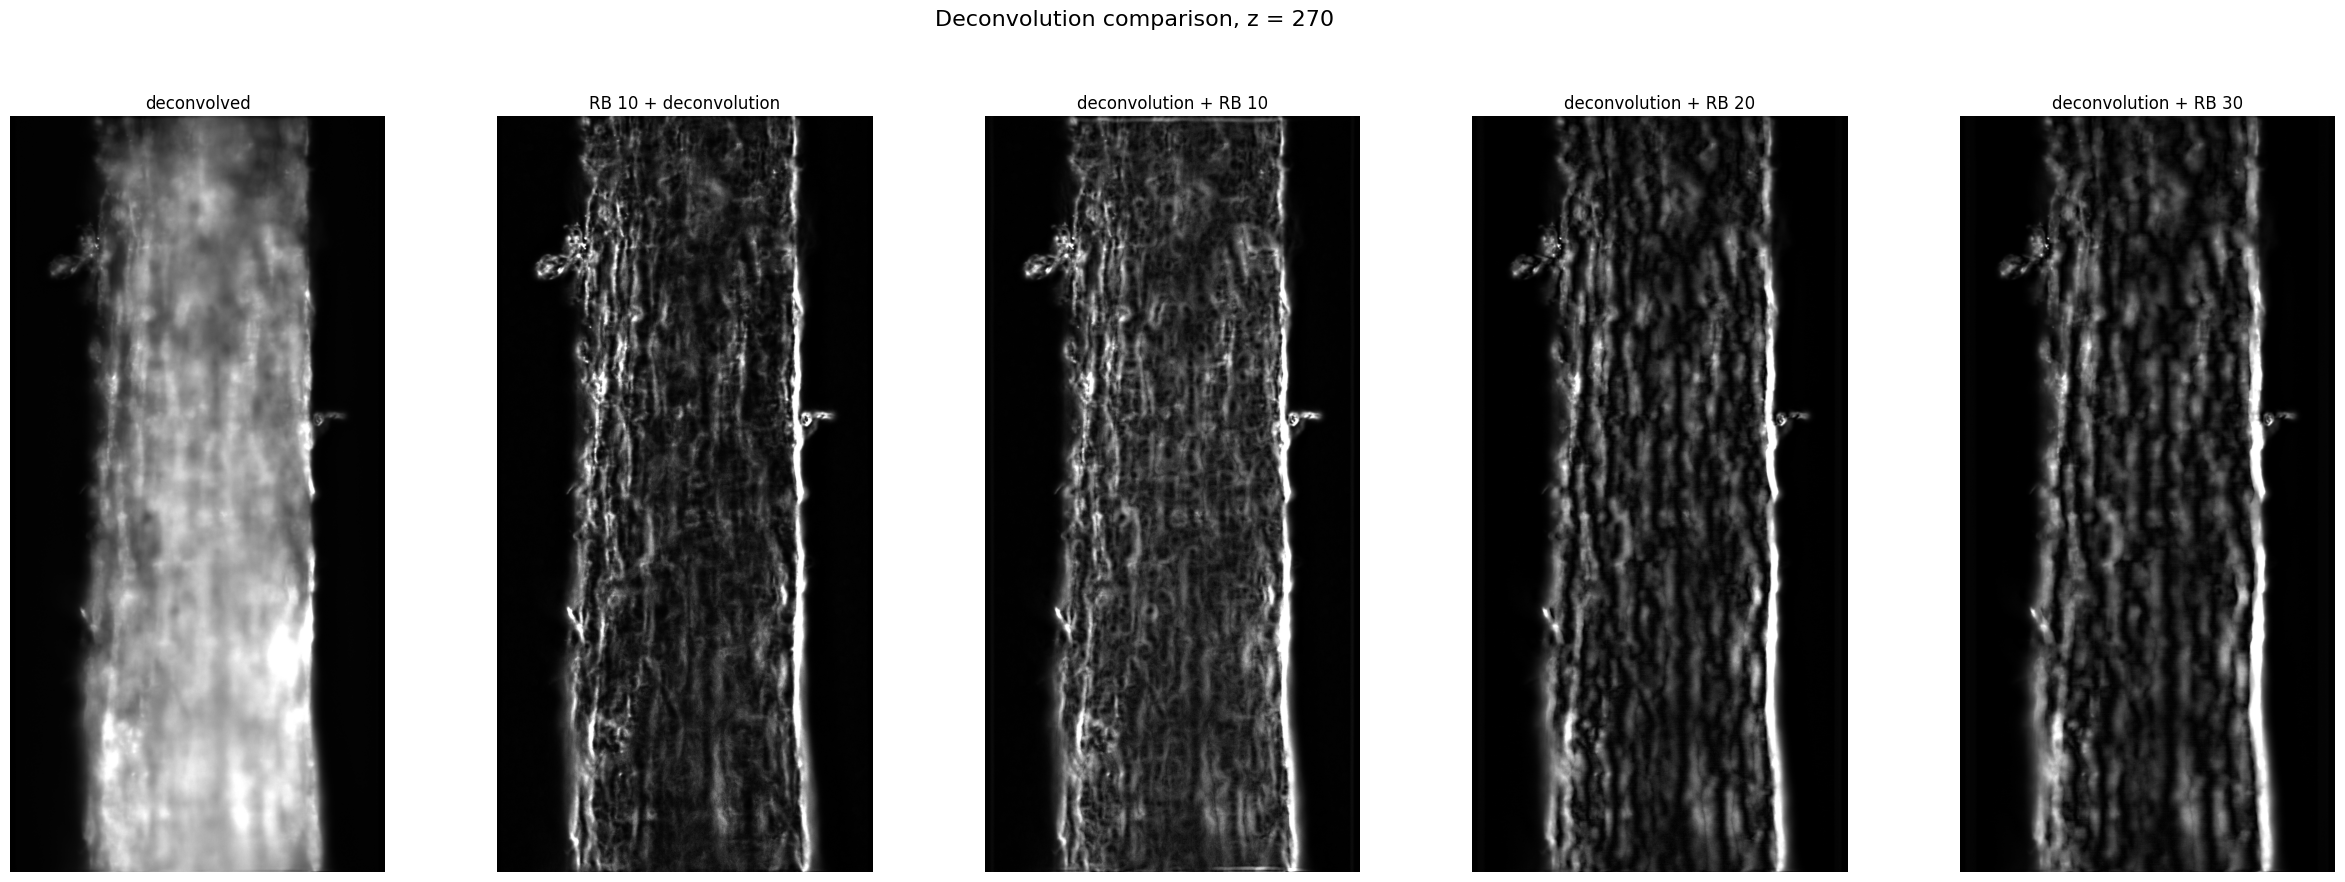

In [57]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(1, 5, figsize=(30, 10), gridspec_kw={'wspace': 0.3})

ax[0].imshow(deconvolved_img[270], cmap='gray', vmax=np.percentile(deconvolved_img[270], 99))
ax[0].set_title("deconvolved")
ax[1].imshow(deconvolution_first_background_subtracted_rolling[270], cmap='gray', vmax=np.percentile(deconvolution_first_background_subtracted_rolling[270], 99))
ax[1].set_title("RB 10 + deconvolution")
ax[2].imshow(background_subtracted_rolling_10[270], cmap='gray', vmax=np.percentile(background_subtracted_rolling_10[270], 99))
ax[2].set_title("deconvolution + RB 10")
ax[3].imshow(background_subtracted_rolling_20, cmap='gray', vmax=np.percentile(background_subtracted_rolling_20, 99))
ax[3].set_title("deconvolution + RB 20")
ax[4].imshow(background_subtracted_rolling_30, cmap='gray', vmax=np.percentile(background_subtracted_rolling_30, 99))
ax[4].set_title("deconvolution + RB 30")


fig.suptitle('Deconvolution comparison, z = 270', fontsize=16)

for a in ax:
    a.axis('off')

plt.show()

In [14]:
# save the full background_subtracted_rolling_full image 
io.imsave(BASE_DIR / 'data/preprocessed/first_deconvolved_then_background_removed_r20_img.tiff', background_subtracted_rolling_20)

NameError: name 'background_subtracted_rolling_20' is not defined

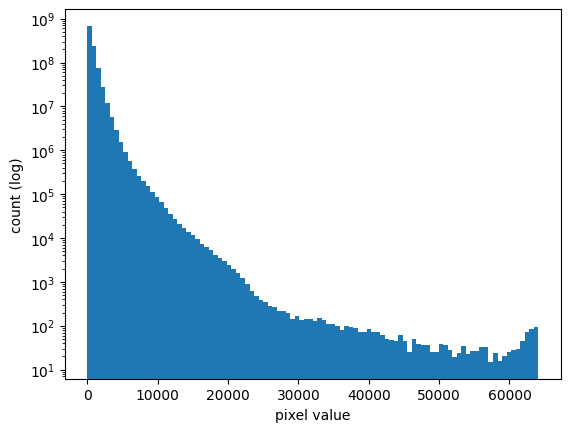

0 64068


In [13]:
# # visualize the changes as histogram to see how much the image has changed 
import numpy as np
import matplotlib.pyplot as plt

# look at the actual value distribution
plt.hist(background_subtracted_rolling.ravel(), bins=100)
plt.yscale('log')
plt.xlabel('pixel value')
plt.ylabel('count (log)')
plt.show()

print(background_subtracted_rolling.min(), background_subtracted_rolling.max())

### 2. Deconvolution

#### 2.1 PSF Centering

In [6]:
psf_path = 'PSF_488nm_cnx.h5'
psf_name = 'PSF_488'

In [7]:
# open the psf file has dtype float32
with h5py.File(BASE_DIR/'data/raw/experimental_PSF'/psf_path, "r") as f:
    psf = f[f'{psf_name}/ImageData/Image'][:]
    psf_info = f[f'{psf_name}/ImageData/Image']
    # f.visit(print) # show all keys

    # find out what axis corresponds the which scale: 
    print("shape of PSF:", psf_info.shape)
    print("number of dims:", len(psf_info.dims))

    for i, dim in enumerate(psf_info.dims):
        print("axis", i, "number of attached scales:", len(dim))

shape of PSF: (1, 1, 192, 40, 40)
number of dims: 5
axis 0 number of attached scales: 0
axis 1 number of attached scales: 1
axis 2 number of attached scales: 1
axis 3 number of attached scales: 1
axis 4 number of attached scales: 1


In [8]:
psf.dtype

dtype('float32')

In [9]:
psf.shape

(1, 1, 192, 40, 40)

In [10]:
# reduce PSF by the first 2 dimensions 
psf_reduced = psf[0,0]
psf_reduced.shape

(192, 40, 40)

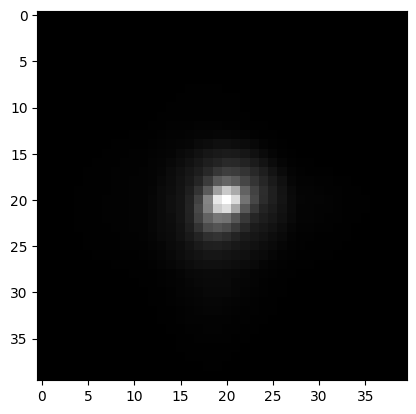

In [11]:
stackview.imshow(psf_reduced, axes = True )

In [12]:
# find the brightest slide 
brightest_slide = preproc.brightest_slice(psf_reduced)
print("The brightest slide index:", brightest_slide)

The brightest slide index: 80


In [13]:
# center the psf
psf_centered = preproc.center_psf(psf_reduced, brightest_slide)

Centering PSF: Shifting peak from slice 80 to 96 (Shift: +16 slices)


In [14]:
# normalize psf
psf_normalized = preproc.normalize_psf(psf_centered)
print("normalized sum should be 1: ", psf_normalized.sum())

normalized sum should be 1:  1.0


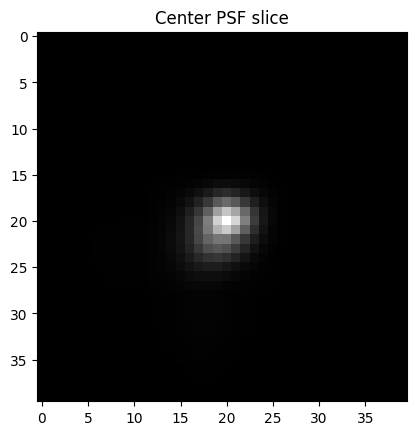

In [15]:
stackview.imshow(psf_normalized[psf_normalized.shape[0]//2], colormap='gray', title="Center PSF slice", axes = True)

max value:  0.007673541
max value index:  96


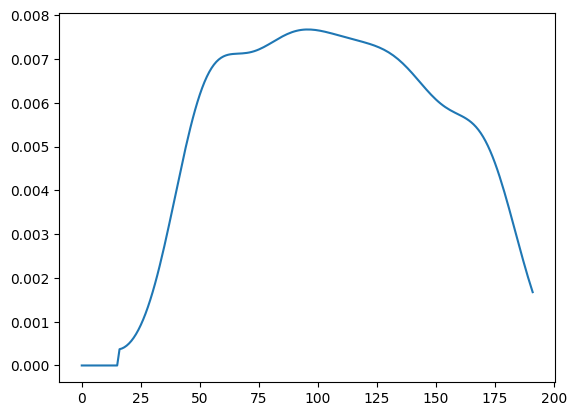

In [16]:
# plot PSF histogram 
intensity_array = psf_normalized.sum(axis=(1,2))
plt.plot(intensity_array)
plt.savefig(BASE_DIR/'results'/'psf_preparation'/"psf_histogram_centered.png")
max_value = max(psf_normalized.sum(axis=(1,2)))
print("max value: ", max_value)
print("max value index: ", list(intensity_array).index(max_value))   # the centering shifted the center index only by 16 steps

<Figure size 640x480 with 0 Axes>

In [40]:
# save psf  
io.imsave(Path(BASE_DIR/'data'/'preprocessed'/f"{psf_name}_centered.tiff"), psf_normalized)

/home/rck292/cardiac_env/lib/python3.11/site-packages/skimage/_shared/utils.py:386: UserWarning: /home/rck292/Project/data/preprocessed/PSF_488_centered.tiff is a low contrast image
  return func(*args, **kwargs)


#### 2.2. Richardson Lucy 

In [17]:
#load centered and normalized PSF
psf_centered = io.imread(BASE_DIR/'data'/'preprocessed'/'PSF_488_centered.tiff')

# load background substracted image
raw_image = cnx_img
# raw_image = io.imread(BASE_DIR/'data'/'preprocessed'/'background_removed_img.tiff')

In [18]:
#check if noramlized [0,1]
psf_normalized = psf_centered / psf_centered.sum()
psf_normalized.sum()

np.float32(1.0)

In [19]:
image_float32 = raw_image.astype(np.float32)
print(f"Converted image from {raw_image.dtype} to {image_float32.dtype}")

Converted image from uint16 to float32


In [20]:
import RedLionfishDeconv as rl

result = rl.doRLDeconvolutionFromNpArrays(
    image_float32, psf_normalized,
    niter=7, method='gpu'  # falls back to CPU if no GPU available
)

/home/rck292/cardiac_env/lib/python3.11/site-packages/pyopencl/__init__.py:570: CompilerWarning: Non-empty compiler output encountered. Set the environment variable PYOPENCL_COMPILER_OUTPUT=1 to see more.
  lambda: self._prg.build(options_bytes, devices),


In [21]:
# save deconvolved image 
io.imsave(BASE_DIR /'data/preprocessed/deconvolved_img.tiff', result)

In [7]:
result.dtype

dtype('float32')

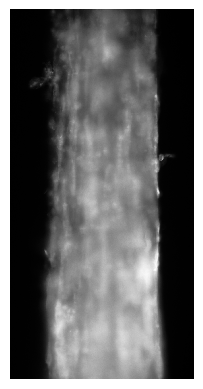

In [23]:
stackview.imshow(raw_image[270]) 